In [1]:
# import modules
import openslide
import cv2
import numpy as np
from utils import *
from matplotlib import pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import math
import os
import fft_poisson_solver_opt
import fft_poisson_solver
import imageio
from PIL import Image
import torch
import tvl1_poisson_solver

pyFFTW will use up to 64 threads.


In [2]:
slide_image = Image.open("../data/slide_image_level_0_cropped.png")

In [3]:
slide_image_array = np.array(slide_image)
channel = "L"
if channel == "r":
    slide_image = slide_image_array[:, :, 2]
elif channel == "g":
    slide_image = slide_image_array[:, :, 1]
elif channel == "b":
    slide_image = slide_image_array[:, :, 0]
elif channel == "L":
    slide_image = slide_image.convert("L")
    slide_image = np.array(slide_image)
print(slide_image.shape)
cropped_size_h, cropped_size_w = 4000, 4000
H, W = 1000, 40 # H, W
threshold = 0.05
speed = 1
noise_level = 0.01
kernel_size = (H, W)
left_offset, top_offset = 0, 0
slide_image_cropped = slide_image[top_offset:top_offset+cropped_size_h, left_offset:left_offset+cropped_size_w]
# plt.imshow(slide_image_cropped, cmap="gray")
# Convert to linear (Gamma :  2.2)
# slide_image = np.power(slide_image / 255.0, 2.2)
slide_image_cropped = np.power(slide_image_cropped / 255.0, 2.2)

(4000, 4000)


In [4]:
"""
Simulating the 2D scanning process on X direction (without any distortion), the smallest movement is 1 pixel. The scanning speed is known as the input. Scanning from  left to right, using a kernel of size (H, H)
Input: 
    (linear) grayscale image (W, H, 1)
    scanning speed (pixels per ms)
    threshold (default = 0.1)
    kernel size (default = 720, 720)
Output:
    events (t, x, y, p)
"""

def scan_image_x(image, speed=1, threshold=0.1, kernel_size=(720, 720), noise_level=0.0):
    height, width = image.shape
    print("height: ", height, "width: ", width)
    log_image = lin_log(image, threshold=20)
    print("np.max(log_image): ", np.max(log_image))
    print("np.min(log_image): ", np.min(log_image))
    # log_image = image
    events = []
    coords = []
    threshold = np.linspace(threshold, 1.2, kernel_size[1])

    for j in range(0, math.ceil(height/kernel_size[0])):
        brightness_buffer = log_image[min(j*kernel_size[0], height-kernel_size[0]):min((j+1)*kernel_size[0], height), 0:kernel_size[1]].copy() # Need deep copy !!!
        for i in tqdm(range(1, width-kernel_size[1], int(speed))):
            current_brightness = log_image[min(j*kernel_size[0], height-kernel_size[0]):min((j+1)*kernel_size[0], height), i:i+kernel_size[1]]
            brightness_diff = current_brightness - brightness_buffer
            if noise_level > 0:
                noise = np.random.normal(0, noise_level, brightness_diff.shape)
                brightness_diff = brightness_diff + noise
            mask = np.abs(brightness_diff) > threshold
            brightness_buffer[mask] = current_brightness[mask]
            y_indices, x_indices = np.where(mask)
            polarities = np.where(brightness_diff[mask] > 0, 1, 0)
            events.append(np.stack((np.full_like(x_indices, j*(width - kernel_size[1])+i), x_indices, y_indices, polarities), axis=-1))
            # append top-left corner coordinates of the kernel
            coords.append([min(j*kernel_size[0], height-kernel_size[0]), i])
    print("i, j: ", i, j)

    events = np.concatenate(events, axis=0, dtype=np.float32)
    events_dtype = np.dtype([('t', np.float32), ('x', np.int32), ('y', np.int32), ('p', bool)])
    structured_events = np.zeros(events.shape[0], dtype=events_dtype)
    structured_events['t'] = events[:, 0]
    structured_events['x'] = events[:, 1]
    structured_events['y'] = events[:, 2]
    structured_events['p'] = events[:, 3].astype(bool)

    coords = np.array(coords, dtype=np.int32)
    return structured_events, coords

In [5]:
def generate_indices(i, j, kernel_size):
    """
    Generate the indices to get the user-defined training postions
    """
    cut_num = i // kernel_size + 1
    base_indices = [k * i // cut_num for k in range(cut_num)] + [i - 1]
    indices_x = [index + i * l for l in range(4) for index in base_indices]
    return indices_x

In [6]:
# Display the events
def display_events(events, height=720, width=720):
    unique_times = np.unique(events['t'])
    downsampled_times = unique_times[::200]

    fig = plt.figure()
    ims = []
    def create_frame(time):
        event_image = np.zeros((height, width), dtype=np.int8)
        mask = events['t'] == time
        masked_events = events[mask]
        event_image[masked_events['y'], masked_events['x']] = np.where(masked_events['p'], 1, -1)
        im = plt.imshow(event_image, animated=True, vmax=1, vmin=-1)
        return [im]


    for time in tqdm(downsampled_times):
        im = create_frame(time)
        ims.append(im)

    ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True)
    # ani.save('../results/animation_histopathology_y.mp4', writer='ffmpeg')
    return ani

In [7]:
event_x, coord_x = scan_image_x(slide_image_cropped, speed=1, threshold=threshold, kernel_size=(H, W), noise_level=noise_level)
print("Event x shape: ", event_x.shape, "Coord x shape: ", coord_x.shape)

height:  4000 width:  4000
np.max(log_image):  5.54126355
np.min(log_image):  1.30744282


100%|██████████| 3959/3959 [00:03<00:00, 1022.32it/s]


i, j:  3959 3
Event x shape:  (56214678,) Coord x shape:  (15836, 2)


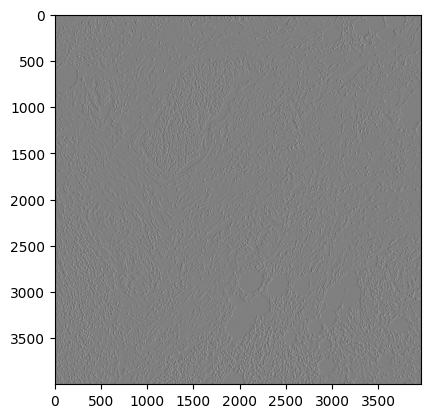

In [8]:
def merge_events_x(events, scan_h=720, scan_w=720, origin_h=6000, origin_w=6000):
    """
    Merge the events into a single array of events (vectorized version)
    Uses np.add.at to accumulate values at duplicate indices
    """
    events_merged = np.zeros((origin_h, origin_w - scan_w), dtype=np.int8)
    
    # Vectorized computation of indices
    height, width = events_merged.shape
    row_idx = (events['y'] + (events['t'] // width) * scan_h).astype(np.int64)
    col_idx = (events['x'] + (events['t'] % width)).astype(np.int64)
    
    # Filter valid indices (within bounds)
    valid_mask = (row_idx >= 0) & (row_idx < height) & (col_idx >= 0) & (col_idx < width)
    
    if np.any(valid_mask):
        row_idx_valid = row_idx[valid_mask]
        col_idx_valid = col_idx[valid_mask]
        p_valid = events['p'][valid_mask]
        
        # Convert bool to int8: True -> 1, False -> -1
        p_values = np.where(p_valid, 1, -1).astype(np.int8)
        
        # Use np.add.at to accumulate values at duplicate indices
        np.add.at(events_merged, (row_idx_valid, col_idx_valid), p_values)
    
    return events_merged

events_merged_x = merge_events_x(event_x, scan_h=H, scan_w=W, origin_h=cropped_size_h, origin_w=cropped_size_w)
plt.imshow(events_merged_x, cmap="gray")

In [9]:
"""
Simulating the 2D scanning process on X direction (without any distortion), the smallest movement is 1 pixel. The scanning speed is known as the input. Scanning from  left to right, using a kernel of size (H, H)
Input: 
    (linear) grayscale image (W, H, 1)
    scanning speed (pixels per ms)
    threshold (default = 0.1)
    kernel size (default = 720, 720)
Output:
    events (t, x, y, p)
"""

def scan_image_y(image, speed=1, threshold=0.1, kernel_size=(720, 720), noise_level=0.0):
    height, width = image.shape
    log_image = lin_log(image, threshold=20)
    # log_image = image
    events = []
    coords = []

    threshold = np.linspace(threshold, 1.2, kernel_size[0])
    for j in range(0, math.ceil(width/kernel_size[1])):
        brightness_buffer = log_image[0:kernel_size[0], min(j*kernel_size[1], width-kernel_size[1]):min((j+1)*kernel_size[1], width)].copy()
        for i in tqdm(range(1, height-kernel_size[0], int(speed))):
            current_brightness = log_image[i:i+kernel_size[0], min(j*kernel_size[1], width-kernel_size[1]):min((j+1)*kernel_size[1], width)]
            brightness_diff = current_brightness - brightness_buffer
            if noise_level > 0:
                noise = np.random.normal(0, noise_level, brightness_diff.shape)
                brightness_diff = brightness_diff + noise
            mask = np.abs(brightness_diff) > threshold[:, np.newaxis]
            brightness_buffer[mask] = current_brightness[mask]
            y_indices, x_indices = np.where(mask)
            polarities = np.where(brightness_diff[mask] > 0, 1, 0)
            events.append(np.stack((np.full_like(x_indices, j*(height - kernel_size[0])+i), x_indices, y_indices, polarities), axis=-1))
            # append top-left corner coordinates of the kernel
            coords.append([i, min(j*kernel_size[1], width-kernel_size[1])])

    print("i, j: ", i, j)

    events = np.concatenate(events, axis=0, dtype=np.float32)
    events_dtype = np.dtype([('t', np.float32), ('x', np.int32), ('y', np.int32), ('p', bool)])
    structured_events = np.zeros(events.shape[0], dtype=events_dtype)
    structured_events['t'] = events[:, 0]
    structured_events['x'] = events[:, 1]
    structured_events['y'] = events[:, 2]
    structured_events['p'] = events[:, 3].astype(bool)

    coords = np.array(coords, dtype=np.int32)
    return structured_events, coords


In [10]:
event_y, coord_y = scan_image_y(slide_image_cropped, speed=1, threshold=threshold, kernel_size=(W, H), noise_level=noise_level)

100%|██████████| 3959/3959 [00:03<00:00, 1104.91it/s]


i, j:  3959 3


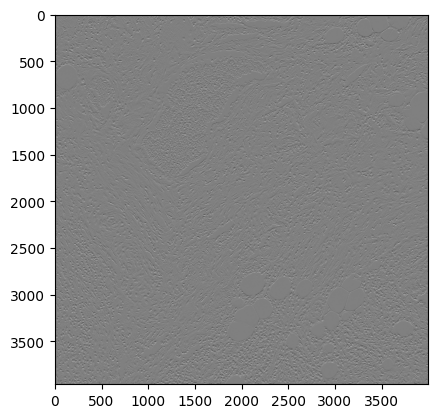

In [11]:
def merge_events_y(events, scan_h=720, scan_w=720, origin_h=6000, origin_w=6000):
    """
    Merge the events into a single array of events (vectorized version)
    Uses np.add.at to accumulate values at duplicate indices
    """
    events_merged = np.zeros((origin_h-scan_h, origin_w), dtype=np.int8)
    
    # Vectorized computation of indices
    height, width = events_merged.shape
    row_idx = (events['y'] + (events['t'] % height)).astype(np.int64)
    col_idx = (events['x'] + (events['t'] // height) * scan_w).astype(np.int64)
    
    # Filter valid indices (within bounds)
    valid_mask = (row_idx >= 0) & (row_idx < height) & (col_idx >= 0) & (col_idx < width)
    
    if np.any(valid_mask):
        row_idx_valid = row_idx[valid_mask]
        col_idx_valid = col_idx[valid_mask]
        p_valid = events['p'][valid_mask]
        
        # Convert bool to int8: True -> 1, False -> -1
        p_values = np.where(p_valid, 1, -1).astype(np.int8)
        
        # Use np.add.at to accumulate values at duplicate indices
        np.add.at(events_merged, (row_idx_valid, col_idx_valid), p_values)
    
    return events_merged

events_merged_y = merge_events_y(event_y, scan_h=W, scan_w=H, origin_h=cropped_size_h, origin_w=cropped_size_w)
plt.imshow(events_merged_y, cmap="gray")

In [13]:
events_merged_x_cropped = events_merged_x[1:cropped_size_h-W, 0:cropped_size_w-W-1]
events_merged_y_cropped = events_merged_y[0:cropped_size_h-W-1, 1:cropped_size_w-W]
events_merged_x_cropped = events_merged_x_cropped.astype(np.float32)
events_merged_y_cropped = events_merged_y_cropped.astype(np.float32)
events_merged_x_cropped = events_merged_x_cropped / np.abs(events_merged_x_cropped).max()
events_merged_y_cropped = events_merged_y_cropped / np.abs(events_merged_y_cropped).max()

print(events_merged_x_cropped.shape, events_merged_y_cropped.shape)


(3959, 3959) (3959, 3959)


In [14]:
grad_x_torch = torch.from_numpy(events_merged_x_cropped)
grad_y_torch = torch.from_numpy(events_merged_y_cropped)
with torch.no_grad(): # Disable autograd to save huge memory and speed up
    reconstructed_gpu, p_gpu = tvl1_poisson_solver.tv_l1_reconstruction_cuda(
        grad_x_torch, 
        grad_y_torch, 
        lambda_tv=1.0, 
        n_iters=6600, 
        device='cuda:1'
    )
event_reconstructed = reconstructed_gpu.cpu().numpy()
print(f"Shape: {event_reconstructed.shape}")
print(f"Min: {np.min(event_reconstructed)}")
print(f"Max: {np.max(event_reconstructed)}")

Shape: (3959, 3959)
Min: -4.8183159828186035
Max: 1.723287582397461


In [15]:
# event_reconstructed = -fft_poisson_solver.poisson_solver(events_merged_x_cropped, events_merged_y_cropped)

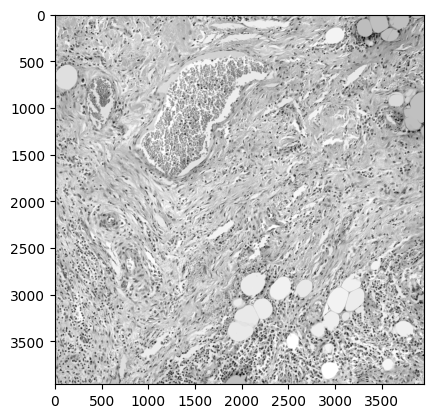

In [16]:
# Normalize to [0,1] range
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))
# # Exponentiate the reconstructed values to linearize the image
event_reconstructed = np.exp(event_reconstructed)
# # Apply gamma correction with gamma=2.2
event_reconstructed = event_reconstructed ** (1/2.2)
#  Normalize to [0,1] range
event_reconstructed = (event_reconstructed - np.min(event_reconstructed)) / (np.max(event_reconstructed) - np.min(event_reconstructed))

# # BLOCK: Auto HDR based on histogram analysis
hist, bins = np.histogram(event_reconstructed.flatten(), bins=65536)
cumsum = np.cumsum(hist)
cumsum = cumsum / cumsum[-1] # Normalize to [0,1]

# Find points for histogram equalization 
low_percentile = 15/65535  # Bottom 0.000015%
high_percentile = 65000/65535 # Top 0.000015%

# Find the intensity values at these percentiles
low_value = bins[np.where(cumsum > low_percentile)[0][0]]
high_value = bins[np.where(cumsum > high_percentile)[0][0]]

# Apply exposure adjustment based on histogram analysis
exposure_factor = 1.0 / (high_value - low_value)
event_reconstructed = (event_reconstructed - low_value) * exposure_factor

# Clip to ensure values stay in [0,1] range after exposure increase
event_reconstructed = np.clip(event_reconstructed, 0, 1)
# Convert to 0-255 range
event_reconstructed = (event_reconstructed * 255).astype(np.uint8)
# Save using imageio

# imageio.imwrite("../results/simulation/reconstructed_downsampled_8x.png", event_reconstructed[::8, ::8])
# imageio.imwrite("../results/simulation/reconstructed_l1.png", event_reconstructed)
plt.imshow(event_reconstructed, cmap="gray")